In [3]:
import os
import time

os.environ["TZ"] = "UTC"
time.tzset()

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import scipy.ndimage as nd
import cmocean
import xarray as xa
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.ticker as mticker

import matplotlib.colors as mcolors
import matplotlib.cm as mplcm

from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

import datetime

import math

from cartopy.feature import LAND
from cartopy.feature import OCEAN

from data_tools import dict_extracted_data, dict_extracted_data_2018, dict_extracted_data_2021, load_sic
from data_tools import generate_lists_data, instrument_label, ColormapMapper

%matplotlib inline

/home/jrmet/Desktop/Git/periodic_oscillation_wave_damping_2021_svalbard_waves_in_ice_arven_etter_nansen/cleaned_notebooks/maps_CICE5_divuh/data_tools.py:70: UserWarning: Warning: converting a masked element to nan.
  crrt_dict_wave["swh"] = float(array_swh[crrt_index])
/home/jrmet/Desktop/Git/periodic_oscillation_wave_damping_2021_svalbard_waves_in_ice_arven_etter_nansen/cleaned_notebooks/maps_CICE5_divuh/data_tools.py:73: UserWarning: Warning: converting a masked element to nan.
  crrt_dict_wave["tz0"] = float(array_tz0[crrt_index])


In [4]:
print("***** configure matplotlib")
plt.rcParams.update({'font.size': 20})
list_colors = list(mcolors.TABLEAU_COLORS)
list_colors.append("k")

NUM_COLORS = 20

cm = plt.get_cmap('gist_rainbow')
cNorm = mcolors.Normalize(vmin=0, vmax=NUM_COLORS - 1)
scalarMap = mplcm.ScalarMappable(norm=cNorm, cmap=cm)

***** configure matplotlib


In [5]:
event_1_start = datetime.datetime(2021, 3, 1, 0, 0, 0)
event_1__stop = datetime.datetime(2021, 3, 3, 23, 59, 59)

list_most_relevant_instruments = [
    "19648",
    "200905",
    "13319",
]

dict_lists_data = generate_lists_data(
    dict_extracted_data,
    list_most_relevant_instruments,
    event_1_start,
    event_1__stop
)

In [6]:
# READ DATA

# Sea ice convergence/divergence
sic = xa.open_dataset( '../../common_nc_data/ice_his.an.20210301.nc')                    
sic1 = xa.open_dataset('../../common_nc_data/ice_his.an.20210302.nc')                    
sic2 = xa.open_dataset('../../common_nc_data/ice_his.an.20210303.nc') 

In [7]:
# Concatenate subset of sea ice convergence data

ds_concat=xa.concat((sic.divu_h.isel(nj=np.arange(350,650),ni=np.arange(100,500)),
                     sic1.divu_h.isel(nj=np.arange(350,650),ni=np.arange(100,500)),
                     sic2.divu_h.isel(nj=np.arange(350,650),ni=np.arange(100,500))),
                    dim='time')#,data_vars=['divu_h','forecast_reference_time'])

In [8]:
ds_concat

<xarray.DataArray 'divu_h' (time: 72, nj: 300, ni: 400)>
array([[[ -62.088116 ,  -75.64215  , -101.49446  , ...,    0.       ,
            0.       ,    0.       ],
        [ -50.247383 ,  -73.73148  , -111.65885  , ...,    0.       ,
            0.       ,    0.       ],
        [ -33.85958  ,  -45.696953 ,  -75.62282  , ...,    0.       ,
            0.       ,    0.       ],
        ...,
        [   3.260686 ,    3.1583087,    2.9489276, ...,    0.       ,
            0.       ,    0.       ],
        [   3.2358906,    3.3665588,    3.3844807, ...,    0.       ,
            0.       ,    0.       ],
        [   2.933282 ,    3.273795 ,    3.4607031, ...,    0.       ,
            0.       ,    0.       ]],

       [[ -65.4821   ,  -64.55626  ,  -79.53288  , ...,    0.       ,
            0.       ,    0.       ],
        [ -50.344025 ,  -60.29653  ,  -82.719124 , ...,    0.       ,
            0.       ,    0.       ],
        [ -43.11196  ,  -46.319263 ,  -57.344093 , ...,    0.       ,
            0.       ,    0.       ],
...
        [   8.836645 ,    8.276139 ,    4.732638 , ...,    0.       ,
            0.       ,    0.       ],
        [  10.5999775,   10.176837 ,    5.819824 , ...,    0.       ,
            0.       ,    0.       ],
        [   9.204792 ,    8.938511 ,    5.12543  , ...,    0.       ,
            0.       ,    0.       ]],

       [[ -45.59657  ,  -68.28089  ,  -50.58992  , ...,    0.       ,
            0.       ,    0.       ],
        [ -66.19234  , -102.050835 ,  -85.76691  , ...,    0.       ,
            0.       ,    0.       ],
        [ -51.458855 ,  -37.28844  ,  -63.48411  , ...,    0.       ,
            0.       ,    0.       ],
        ...,
        [   7.634938 ,    6.488877 ,    2.4960408, ...,    0.       ,
            0.       ,    0.       ],
        [  10.164103 ,    8.317129 ,    2.9713054, ...,    0.       ,
            0.       ,    0.       ],
        [   9.39525  ,    7.032748 ,    1.1978136, ...,    0.       ,
            0.       ,    0.       ]]], dtype=float32)
Coordinates:
    TLAT     (nj, ni) float32 76.45 76.44 76.43 76.42 ... 75.19 75.17 75.15
    TLON     (nj, ni) float32 355.7 355.8 355.9 356.0 ... 42.23 42.26 42.3 42.33
    ULAT     (nj, ni) float32 76.45 76.45 76.44 76.43 ... 75.2 75.18 75.16 75.14
    ULON     (nj, ni) float32 -4.23 -4.14 -4.05 -3.96 ... 42.32 42.36 42.39
  * time     (time) datetime64[ns] 2021-03-01 ... 2021-03-03T23:00:00
Dimensions without coordinates: nj, ni
Attributes:
    units:          %/day
    long_name:      strain rate (divergence)
    cell_measures:  area: tarea
    time_rep:       instantaneous

In [9]:
ds_concat_aice_h = xa.concat((sic.aice_h.isel(nj=np.arange(350,650),ni=np.arange(100,500)),
                     sic1.aice_h.isel(nj=np.arange(350,650),ni=np.arange(100,500)),
                     sic2.aice_h.isel(nj=np.arange(350,650),ni=np.arange(100,500))),
                    dim='time')#,data_vars=['divu_h','forecast_reference_time'])

In [21]:
ds_concat_aice_h

<xarray.DataArray 'aice_h' (time: 72, nj: 300, ni: 400)>
array([[[0.23429646, 0.23966563, 0.22494188, ..., 0.        ,
         0.        , 0.        ],
        [0.22948411, 0.27899757, 0.2968437 , ..., 0.        ,
         0.        , 0.        ],
        [0.19963934, 0.26197898, 0.35228428, ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.9308797 , 0.9369538 , 0.93952125, ..., 0.        ,
         0.        , 0.        ],
        [0.9357364 , 0.9413509 , 0.9396752 , ..., 0.        ,
         0.        , 0.        ],
        [0.93850255, 0.943571  , 0.9381375 , ..., 0.        ,
         0.        , 0.        ]],

       [[0.23071583, 0.24460447, 0.23316455, ..., 0.        ,
         0.        , 0.        ],
        [0.21783124, 0.27244022, 0.31466308, ..., 0.        ,
         0.        , 0.        ],
        [0.19199465, 0.22934033, 0.34937033, ..., 0.        ,
         0.        , 0.        ],
...
        [0.8991748 , 0.92663425, 0.9343537 , ..., 0.        ,
         0.        , 0.        ],
        [0.8909965 , 0.9125689 , 0.9271562 , ..., 0.        ,
         0.        , 0.        ],
        [0.8835641 , 0.8978305 , 0.92207646, ..., 0.        ,
         0.        , 0.        ]],

       [[0.8405798 , 0.7636288 , 0.6834827 , ..., 0.        ,
         0.        , 0.        ],
        [0.87210214, 0.8075769 , 0.7266083 , ..., 0.        ,
         0.        , 0.        ],
        [0.86068785, 0.8492604 , 0.70381993, ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.89370024, 0.9207742 , 0.9314901 , ..., 0.        ,
         0.        , 0.        ],
        [0.8851852 , 0.90589565, 0.9242042 , ..., 0.        ,
         0.        , 0.        ],
        [0.87860334, 0.892354  , 0.9204551 , ..., 0.        ,
         0.        , 0.        ]]], dtype=float32)
Coordinates:
    TLAT     (nj, ni) float32 76.45 76.44 76.43 76.42 ... 75.19 75.17 75.15
    TLON     (nj, ni) float32 355.7 355.8 355.9 356.0 ... 42.23 42.26 42.3 42.33
    ULAT     (nj, ni) float32 76.45 76.45 76.44 76.43 ... 75.2 75.18 75.16 75.14
    ULON     (nj, ni) float32 -4.23 -4.14 -4.05 -3.96 ... 42.32 42.36 42.39
  * time     (time) datetime64[ns] 2021-03-01 ... 2021-03-03T23:00:00
Dimensions without coordinates: nj, ni
Attributes:
    units:          1
    long_name:      ice area  (aggregate)
    cell_measures:  area: tarea
    time_rep:       instantaneous

In [11]:
# Plotting commands

fs = 14 #font size
crs_kws = dict(projection=ccrs.NorthPolarStereo(), facecolor="0.90")
data_crs = ccrs.PlateCarree()
geodetic = ccrs.Geodetic(globe=ccrs.Globe(datum='WGS84'))

#lscale='full'
lscale='intermediate'
f = cfeature.GSHHSFeature(scale=lscale, levels=[1],
        facecolor=cfeature.COLORS['land'])

# SET plot extent
lonmin, lonmax, latmin, latmax = 20,30,70,80#12.1+0.4, 13.2, 67.7-0.1, 68
plot_extent = [lonmin, lonmax, latmin, latmax ]

In [16]:
ds_concat

<xarray.DataArray 'divu_h' (time: 72, nj: 300, ni: 400)>
array([[[ -62.088116 ,  -75.64215  , -101.49446  , ...,    0.       ,
            0.       ,    0.       ],
        [ -50.247383 ,  -73.73148  , -111.65885  , ...,    0.       ,
            0.       ,    0.       ],
        [ -33.85958  ,  -45.696953 ,  -75.62282  , ...,    0.       ,
            0.       ,    0.       ],
        ...,
        [   3.260686 ,    3.1583087,    2.9489276, ...,    0.       ,
            0.       ,    0.       ],
        [   3.2358906,    3.3665588,    3.3844807, ...,    0.       ,
            0.       ,    0.       ],
        [   2.933282 ,    3.273795 ,    3.4607031, ...,    0.       ,
            0.       ,    0.       ]],

       [[ -65.4821   ,  -64.55626  ,  -79.53288  , ...,    0.       ,
            0.       ,    0.       ],
        [ -50.344025 ,  -60.29653  ,  -82.719124 , ...,    0.       ,
            0.       ,    0.       ],
        [ -43.11196  ,  -46.319263 ,  -57.344093 , ...,    0.       ,
            0.       ,    0.       ],
...
        [   8.836645 ,    8.276139 ,    4.732638 , ...,    0.       ,
            0.       ,    0.       ],
        [  10.5999775,   10.176837 ,    5.819824 , ...,    0.       ,
            0.       ,    0.       ],
        [   9.204792 ,    8.938511 ,    5.12543  , ...,    0.       ,
            0.       ,    0.       ]],

       [[ -45.59657  ,  -68.28089  ,  -50.58992  , ...,    0.       ,
            0.       ,    0.       ],
        [ -66.19234  , -102.050835 ,  -85.76691  , ...,    0.       ,
            0.       ,    0.       ],
        [ -51.458855 ,  -37.28844  ,  -63.48411  , ...,    0.       ,
            0.       ,    0.       ],
        ...,
        [   7.634938 ,    6.488877 ,    2.4960408, ...,    0.       ,
            0.       ,    0.       ],
        [  10.164103 ,    8.317129 ,    2.9713054, ...,    0.       ,
            0.       ,    0.       ],
        [   9.39525  ,    7.032748 ,    1.1978136, ...,    0.       ,
            0.       ,    0.       ]]], dtype=float32)
Coordinates:
    TLAT     (nj, ni) float32 76.45 76.44 76.43 76.42 ... 75.19 75.17 75.15
    TLON     (nj, ni) float32 355.7 355.8 355.9 356.0 ... 42.23 42.26 42.3 42.33
    ULAT     (nj, ni) float32 76.45 76.45 76.44 76.43 ... 75.2 75.18 75.16 75.14
    ULON     (nj, ni) float32 -4.23 -4.14 -4.05 -3.96 ... 42.32 42.36 42.39
  * time     (time) datetime64[ns] 2021-03-01 ... 2021-03-03T23:00:00
Dimensions without coordinates: nj, ni
Attributes:
    units:          %/day
    long_name:      strain rate (divergence)
    cell_measures:  area: tarea
    time_rep:       instantaneous

crrt_datetime = datetime.datetime(2021, 3, 2, 0, 0)
crrt_datetime = datetime.datetime(2021, 3, 2, 6, 0)
crrt_datetime = datetime.datetime(2021, 3, 2, 12, 0)
crrt_datetime = datetime.datetime(2021, 3, 2, 18, 0)


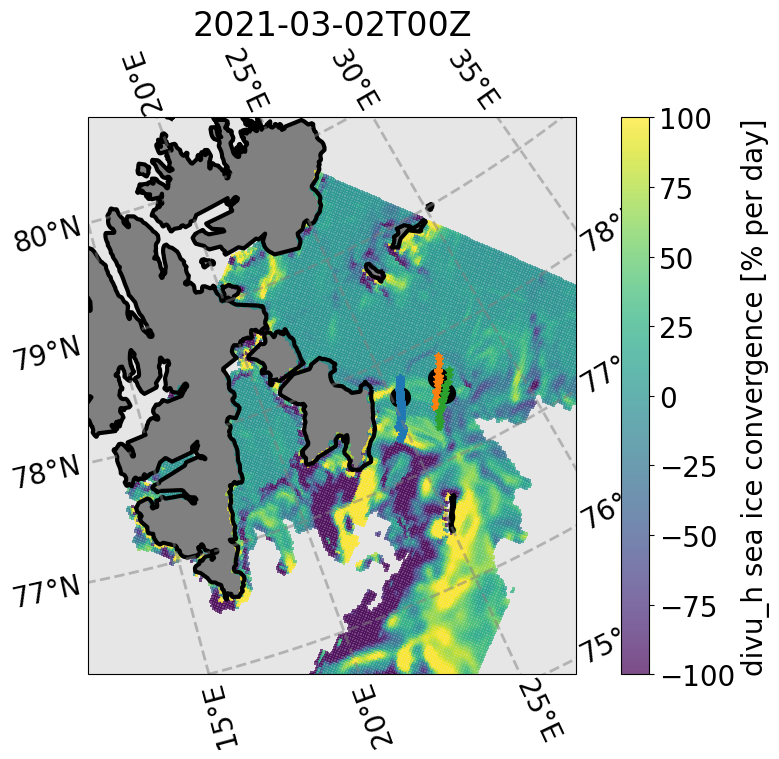

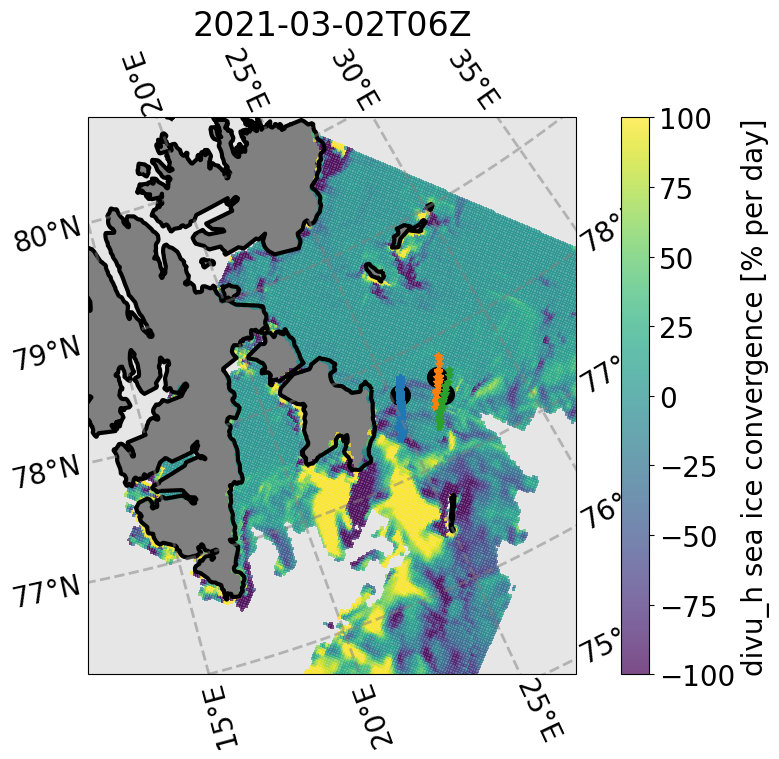

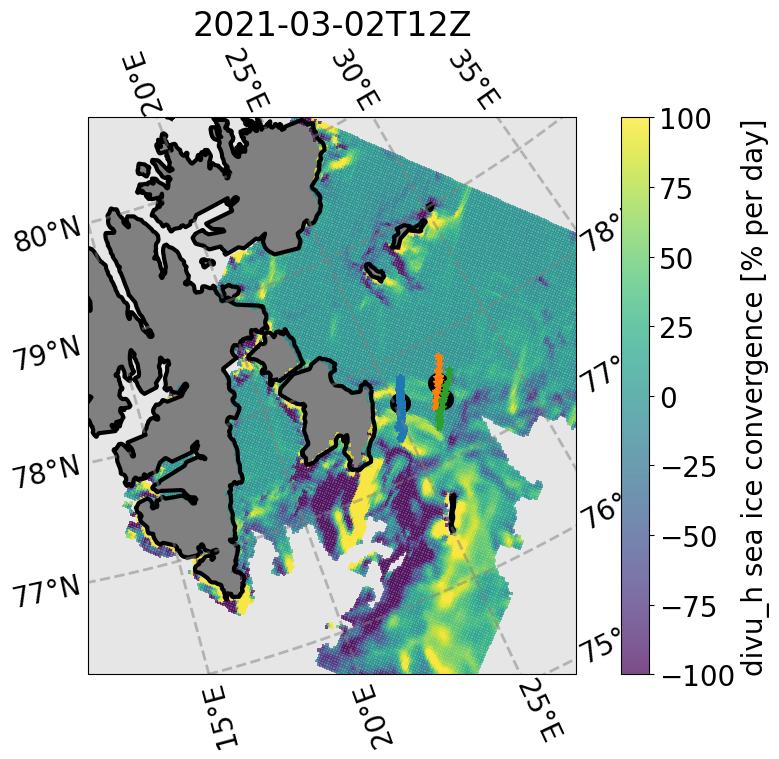

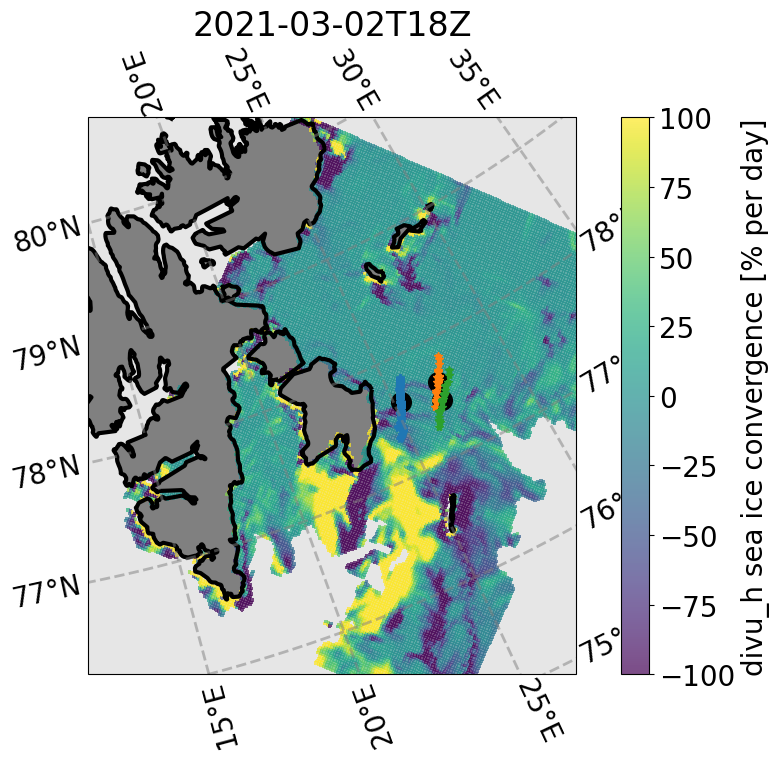

In [27]:
# crrt_time = 40

# for crrt_time in range(0, 40):
for crrt_time in [24, 30, 36, 42]:
    
    fig,ax = plt.subplots(figsize=(10,8), subplot_kw=crs_kws)
    
    crrt_da = ds_concat.isel(time=crrt_time).where(ds_concat_aice_h.isel(time=crrt_time) > 0.25, math.nan, math.nan).isel(nj=np.arange(80,270),ni=np.arange(130,280))
    
    crrt_datetime = datetime.datetime.utcfromtimestamp(float(crrt_da.time.data) / 1e9)
    print(f"{crrt_datetime = }")
    
    im = ax.pcolormesh(crrt_da.TLON, crrt_da.TLAT,crrt_da, transform=data_crs, vmin=-100, vmax=100, alpha=0.7)
    cbar = fig.colorbar(im, orientation='vertical')
    cbar.ax.set_ylabel("divu_h sea ice convergence [% per day]")
    
    ax.coastlines(linewidth=3.0);
    
    ax.add_feature(LAND, color="grey")
    
    for crrt_index, crrt_instrument in enumerate(list_most_relevant_instruments):
        # ic(crrt_instrument)
        ax.plot(
            dict_lists_data[crrt_instrument]["lon"],
            dict_lists_data[crrt_instrument]["lat"],
            marker="*", linestyle="-", alpha=1.0,
            label=instrument_label(crrt_instrument),
            color=list_colors[crrt_index],
            transform=data_crs,
        )
    
        # ic(dict_lists_data[crrt_instrument]["tll"])
        list_timestamps_before = \
            [crrt_timestamp for crrt_timestamp in dict_lists_data[crrt_instrument]["tll"]
                if crrt_timestamp < crrt_datetime
            ]
        if len(list_timestamps_before) == len(dict_lists_data[crrt_instrument]["tll"]):
            continue
        index = len(list_timestamps_before) - 1
        if index == -1:
            continue
        # ic(index)
    
        ax.scatter(
            dict_lists_data[crrt_instrument]["lon"][index],
            dict_lists_data[crrt_instrument]["lat"][index],
            s=200,
            color="black",
            transform=data_crs,
        )
    
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=2, color='gray', alpha=0.5, linestyle='--', x_inline=False, y_inline=False, )
    gl.labels_top = False
    gl.labels_left = True
    gl.labels_right = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    
    plt.title(str(crrt_da.time.data)[0:13] + "Z")

    ax.set_extent([15, 29, 76, 80], crs=ccrs.PlateCarree())
    
    plt.tight_layout()
    
    # plt.savefig(f"div_u_map_{crrt_datetime}.pdf")
    plt.savefig(f"div_u_map_{crrt_datetime}.png")
